<a href="https://colab.research.google.com/github/carlacodes/atchekegroup1lunarlanding/blob/carlabranch/testingvisualisationobstacle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# @title Install dependencies
#! git clone https://github.com/carlacodes/gym-0.21.0.git
%cd /content/gym-0.21.0
!git pull

!sudo apt-get update > /dev/null 2>&1
!sudo apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install rarfile --quiet
!pip install stable-baselines3[extra] ale-py==0.7.4 --quiet
!pip install box2d-py --quiet
!pip install /content/gym-0.21.0
!pip install pyglet==1.4.0
!pip install imageio-ffmpeg
!brew install ffmpeg


# Imports
import io
import os
import glob
import torch
import base64
import stable_baselines3

import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.results_plotter import ts2xy, load_results
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_atari_env

import gym
from gym import spaces
from gym.wrappers import Monitor

/content/gym-0.21.0
Already up to date.
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Processing /content/gym-0.21.0
  DEPRECATION: A future pip version will change local packages to be built in-place without first copying to a temporary directory. We recommend you use --use-feature=in-tree-build to test your packages with this new behavior before it becomes the default.
   pip 21.3 will remove support for this functionality. You can find discussion regarding this at https://github.com/pypa/pip/issues/7555.
  Created wheel for gym: filename=gym-0.21.0-py3-none-any.whl size=1624305 sha256=7a21b1a5d2cd0737193dcf4b55645b3f455dc6b8a542c3afa66c131501d55dff
  Stored in directory: /root/.cache/pip/wheels/c2/a6/33/3f73513a855466e22e7d2622ee20515e3f0b250c7b8f0f53b3
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.21.0
    Uninstalling gym-0.21.0:
      Successfully uninstalled gym-0.21.0
Looking in ind

In [4]:
# @title Plotting/Video functions
from IPython.display import HTML
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay

display = Display(visible=0, size=(1400, 900))
display.start()

"""
Utility functions to enable video recording of gym environment
and displaying it.
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = Monitor(env, './video', force=True)
  # env = RecordVideo(env, './video')
  return env

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 99.4     |
|    ep_rew_mean      | -158     |
|    exploration_rate | 0.89     |
| time/               |          |
|    episodes         | 10       |
|    fps              | 316      |
|    time_elapsed     | 3        |
|    total_timesteps  | 994      |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 1.4      |
|    n_updates        | 992      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 99.3     |
|    ep_rew_mean      | -146     |
|    exploration_rate | 0.88     |
| time/               |          |
|    episodes         | 20       |
|    fps              | 255      |
|    time_elapsed     | 7        |
|    total_timesteps  | 1986     |
| train/              |          |
|    learning_rate    | 0.00063  |
|  

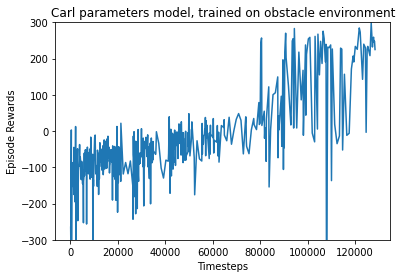

In [5]:
import io
import os
import glob
import torch
import pip
import base64
# import stable_baselines3


import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3
import gym
from stable_baselines3 import DQN
from stable_baselines3.common.results_plotter import ts2xy, load_results
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_atari_env

import gym
from gym import spaces

from gym.wrappers import Monitor,RecordVideo
#
# # @title Plotting/Video functions
# from IPython.display import HTML
# from pyvirtualdisplay import Display
# from IPython import display as ipythondisplay
import torch

# print(f"Is CUDA supported by this system?{torch.cuda.is_available()}")
# print(f"CUDA version: {torch.version.cuda}")

# # Storing ID of current CUDA device
# cuda_id = torch.cuda.current_device()
# print(f"ID of current CUDA device:{torch.cuda.current_device()}")

# print(f"Name of current CUDA device:{torch.cuda.get_device_name(cuda_id)}")
import gym
# cuda = torch.device('cpu')     # Default CUDA device
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# print(device)

# with torch.cuda.device(0):
nn_layers = [64,64] #This is the configuration of your neural network. Currently, we have two layers, each consisting of 64 neurons.
#If you want three layers with 64 neurons each, set the value to [64,64,64] and so on.

learning_rate = 0.001 #This is the step-size with which the gradient descent is carried out.
#Tip: Use smaller step-sizes for larger networks.
env = gym.make('LunarLander-v4', enable_wind=False, wind_power = 0.0)
log_dir = "/tmp/gym2007/"
log_dir='/resultsgym/'
os.makedirs(log_dir, exist_ok=True)

# Create environment

#You can also load other environments like cartpole, MountainCar, Acrobot. Refer to https://gym.openai.com/docs/ for descriptions.
#For example, if you would like to load Cartpole, just replace the above statement with "env = gym.make('CartPole-v1')".

env = stable_baselines3.common.monitor.Monitor(env, log_dir )

callback = EvalCallback(env,log_path = log_dir, deterministic=True) #For evaluating the performance of the agent periodically and logging the results.
policy_kwargs = dict(activation_fn=torch.nn.ReLU,
                     net_arch=nn_layers)
model_old = DQN("MlpPolicy", env,policy_kwargs = policy_kwargs,
                learning_rate=learning_rate,
                batch_size=1,  #for simplicity, we are not doing batch update.
                buffer_size=1, #size of experience of replay buffer. Set to 1 as batch update is not done
                learning_starts=1, #learning starts immediately!
                gamma=0.99, #discount facto. range is between 0 and 1.
                tau = 1,  #the soft update coefficient for updating the target network
                target_update_interval=1, #update the target network immediately.
                train_freq=(1,"step"), #train the network at every step.
                max_grad_norm = 10, #the maximum value for the gradient clipping
                exploration_initial_eps = 0.9, #initial value of random action probability
                exploration_fraction = 0.8, #fraction of entire training period over which the exploration rate is reduced
                gradient_steps = 1, #number of gradient steps,
                exploration_final_eps = 0.05,

                # exploration_initial_eps = 1  # initial value of random action probability. Range is between 0 and 1.
                # exploration_fraction = 0.5  # fraction of entire training period over which the exploration rate is reduced. Range is between 0 and 1.
                # exploration_final_eps = 0.05  # (set by defualt) final value of random action probability. Range is between 0 and 1.
                seed = 1, #seed for the pseudo random generators
                device="cuda",
                verbose=0) #Set verbose to 1 to observe training logs. We encourage you to set the verbose to 1.
model_test = DQN("MlpPolicy", env,policy_kwargs =policy_kwargs,
                 learning_rate=6.3e-4,
                 batch_size=128,  #for simplicity, we are not doing batch update.
                 buffer_size=50000, #size of experience of replay buffer. Set to 1 as batch update is not done
                 learning_starts=0, #learning starts immediately!
                 gamma=0.99, #discount facto. range is between 0 and 1.
                 tau = 1,  #the soft update coefficient for updating the target network
                 target_update_interval=250, #update the target network immediately.
                 train_freq=(4,"step"), #train the network at every step.
                 #max_grad_norm = 10, #the maximum value for the gradient clipping
                 exploration_initial_eps = 0.9, #initial value of random action probability
                 exploration_fraction = 0.8, #fraction of entire training period over which the exploration rate is reduced
                 gradient_steps = -1, #number of gradient steps,
                 exploration_final_eps = 0.1,

                 # exploration_initial_eps = 1  # initial value of random action probability. Range is between 0 and 1.
                 # exploration_fraction = 0.5  # fraction of entire training period over which the exploration rate is reduced. Range is between 0 and 1.
                 # exploration_final_eps = 0.05  # (set by defualt) final value of random action probability. Range is between 0 and 1.
                 seed = 1, #seed for the pseudo random generators
                 device="cuda",
                 verbose=1) #Set verbose to 1 to observe training logs. We encourage you to set the verbose to 1.
# You can also experiment with other RL algorithms like A2C, PPO, DDPG etc. Refer to  https://stable-baselines3.readthedocs.io/en/master/guide/examples.html
#for documentation. For example, if you would like to run DDPG, just replace "DQN" above with "DDPG".
#
# for _ in range(1000):
#     env.render()
#     env.step(env.action_space.sample())
#
# env.close()

"""
Utility functions to enable video recording of gym environment
and displaying it.
To enable video, just do "env = wrap_env(env)""
"""
#

# test_env = (gym.make("LunarLander-v4"))
# observation = test_env.reset()
# total_reward = 0
# while True:
#   test_env.render()
#   # for _ in range(1000):
#   #     env.render()
#   test_env.step(env.action_space.sample())
#   #
#   # env.close()
#   action, states = model_old.predict(observation, deterministic=True)
#   observation, reward, done, info = test_env.step(action)
#   total_reward += reward
#   if done:
#     break
#
# # print(total_reward)
# test_env.close()

#model_old.learn(total_timesteps=100000, log_interval=10, callback=callback)
model_test.learn(total_timesteps=100000, log_interval=10, callback=callback)

x, y = ts2xy(load_results(log_dir), 'timesteps')  # Organising the logged results in to a clean format for plotting.
plt.plot(x, y)
plt.ylim([-300, 300])
plt.xlabel('Timesteps')
plt.ylabel('Episode Rewards')
plt.title('Carl parameters model, trained on obstacle environment')
plt.show()


#run corresponding video with obstacle
# env = (gym.make("LunarLander-v4"))
# #env= Monitor(env, "./gym-results", force=True)
# observation = env.reset()
# env.render()
# total_reward = 0
# while True:
#   env.render()
#   action, _states = model_test.predict(observation, deterministic=True)
#   observation, reward, done, info = env.step(action)
#   if done:
#     break;

# env.close()



In [6]:
# import matplotlib.pyplot as plt
# %matplotlib inline
# from IPython import display

# def show_state(env, step=0, info=""):
#     plt.figure(3)
#     plt.clf()
#     plt.imshow(env.render(mode='rgb_array'))
#     plt.title("%s | Step: %d %s" % (env._spec.id,step, info))
#     plt.axis('off')

#     display.clear_output(wait=True)
#     display.display(plt.gcf())

new_env = wrap_env(gym.make("LunarLander-v4"))
new_env= Monitor(env, "./gym-results", force=True)
observation = new_env.reset()
total_reward = 0

while True:
  new_env.render()
  action, states = model_test.predict(observation, deterministic=True)
  observation, reward, done, info = new_env.step(action)
  total_reward += reward
  if done:
    break;


new_env.close()
show_video()


/content/gym-0.21.0/gym/wrappers/monitor.py:32: UserWarning: The Monitor wrapper is being deprecated in favor of gym.wrappers.RecordVideo and gym.wrappers.RecordEpisodeStatistics (see https://github.com/openai/gym/issues/2297)
  "The Monitor wrapper is being deprecated in favor of gym.wrappers.RecordVideo and gym.wrappers.RecordEpisodeStatistics (see https://github.com/openai/gym/issues/2297)"


Could not find video
